In [1]:
import sys
sys.path.append('/Users/aidanmorson/Desktop/analysis/parkinsons/analysis')
from load_data.load_npz import load_spikedata
from analysis.position_sd import get_neuron_positions


In [2]:
sd24578_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24578_D49-6.zip')
sd24578_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24578_D60+6.zip')
sd24481_49 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d49/24481_D49-6.zip')
sd24481_60 = load_spikedata('/Users/aidanmorson/Desktop/analysis/parkinsons/data-by-day/d60/24481_D60+6.zip')

In [3]:
#acg24481_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/d49/24481_SmitsMO_D49_sect300_20241031_params_default_conn/acg.npz'
fc24481_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/d49/24481_SmitsMO_D49_sect300_20241031_params_default_conn/func_pairs.npz'
#acg24578_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/d49/24578_SmitsMO_D49_sect300_20241031_params_default_conn/acg.npz'
fc24578_49_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/d49/24578_SmitsMO_D49_sect300_20241031_params_default_conn/func_pairs.npz'
acg24481_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/d60/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_params_default_conn/acg.npz'
fc24481_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/d60/24481_SmitsMO_D60_sect300_Control_DIV6_20241112_params_default_conn/func_pairs.npz'
acg24578_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/d60/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_params_default_conn/acg.npz' 
fc24578_60_path = '/Users/aidanmorson/Desktop/analysis/parkinsons/lat-data/d60/24578_SmitsMO_D60_sect300_T2PostDrug175-DIV6_20241112_params_default_conn/func_pairs.npz'

In [4]:
import numpy as np
#acg24481_49 = np.load(acg24481_49_path, allow_pickle=True)
fc24481_49 = np.load(fc24481_49_path, allow_pickle=True)
#acg24578_49 = np.load(acg24578_49_path, allow_pickle=True)
fc24578_49 = np.load(fc24578_49_path, allow_pickle=True)
acg24481_60 = np.load(acg24481_60_path, allow_pickle=True)
fc24481_60 = np.load(fc24481_60_path, allow_pickle=True)
acg24578_60 = np.load(acg24578_60_path, allow_pickle=True)
fc24578_60 = np.load(fc24578_60_path, allow_pickle=True)


In [ ]:
#ac24481_49 = acg24481_49['acg_dict'].item()
#print(len(ac24481_49))
ac24481_60 = acg24481_60['acg_dict'].item()
print(len(ac24481_60))
#ac24578_49 = acg24578_49['acg_dict'].item()
#print(len(ac24578_49))
ac24578_60 = acg24578_60['acg_dict'].item()
print(len(ac24578_60))

In [ ]:
fp24481_49 = fc24481_49['func_pairs'].item()
print(len(fp24481_49))
fp24481_60 = fc24481_60['func_pairs'].item()
print(len(fp24481_60))
fp24578_49 = fc24578_49['func_pairs'].item()
print(len(fp24578_49))
fp24578_60 = fc24578_60['func_pairs'].item()
print(len(fp24578_60))


In [ ]:
#print(ac24481_49.keys())
print(ac24481_60.keys())
#print(ac24578_49.keys())
print(ac24578_60.keys())

In [ ]:
print(fp24481_49.keys())
print(fp24481_60.keys())
print(fp24578_49.keys())
print(fp24578_60.keys())

In [ ]:
list_24481_49 = [list(pair) for pair in fp24481_49.keys()]
list_24481_60 = [list(pair) for pair in fp24481_60.keys()]
list_24578_49 = [list(pair) for pair in fp24578_49.keys()]
list_24578_60 = [list(pair) for pair in fp24578_60.keys()]
print(list_24481_49)
print(list_24481_60) 
print(list_24578_49)
print(list_24578_60)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from analysis.position_sd import get_neuron_positions
from analysis.firing_sd import mean_firing_rates

def plot_functional_connectivity(sd, func_pairs, 
                                                   p_threshold=1e-5, 
                                                   base_scatter_size=50,
                                                   base_line_scale=5,
                                                   max_line_width=10,
                                                   title="Chip ID: Day"):
    """
    Plot neuron positions with functional connectivity lines.
    
    Each functional pair is drawn as an arrow (using annotate with arrowprops)
    with an arrow style that displays a "carrot-like" connection (with tips on both ends).
    
    Neuron marker sizes are scaled according to their mean firing rates multiplied by 5.
    
    Parameters:
      sd : SpikeData object
          Contains neuron positions (retrieved by get_neuron_positions(sd))
          and spike trains for computing firing rates.
      func_pairs : dict
          Dictionary where each key is a tuple (sender, receiver) and each value 
          is a dictionary that includes at least 'p_fast'.
      p_threshold : float, optional
          The p value threshold used in analysis; used to scale the line width.
      base_scatter_size : int, optional
          Base size for scatter plot markers before scaling by firing rate.
      base_line_scale : float, optional
          Base scaling factor for computing line widths from p values.
      max_line_width : float, optional
          Maximum line width (to prevent extreme values).
        title : str, optional
          Chip ID to identify organoid and day of experiment.
    """
    # Get neuron positions (assumed to be an array of shape (n_neurons, 2))
    positions = get_neuron_positions(sd)
    n_neurons = positions.shape[0]
    
    # Compute mean firing rates (Hz) for each neuron.
    rates = mean_firing_rates(sd)
    # Normalize firing rates to a 0-1 scale.
    norm_rates = (rates - rates.min()) / (rates.max() - rates.min() + 1e-9)
    # Scale marker sizes to the firing rates multiplied by 5.
    marker_sizes = base_scatter_size * 4.5 * norm_rates
    
    # For legend examples, compute marker sizes for the 25th and 75th percentiles.
    marker_25 = base_scatter_size * 4.5 * np.percentile(norm_rates, 25)
    marker_75 = base_scatter_size * 4.5 * np.percentile(norm_rates, 75)
    
    # Identify senders and receivers from the functional pairs.
    senders = set()
    receivers = set()
    for (sender, receiver), info in func_pairs.items():
        senders.add(sender)
        receivers.add(receiver)
    senders = np.array(sorted(list(senders)))
    receivers = np.array(sorted(list(receivers)))
    
    # Create the plot.
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot all neurons as green dots, with sizes scaled by firing rate.
    scatter_all = ax.scatter(positions[:, 0], positions[:, 1], color='green', 
                             s=marker_sizes, label='Other Neurons')
    
    # Draw an arrow for each functional pair using annotate with a carrot-like arrow style.
    for (sender, receiver), info in func_pairs.items():
        p_val = info.get('p_fast', 1)  # Default p value if not present
        # Compute line width: lower p values yield thicker lines.
        lw = base_line_scale * (p_threshold / p_val) if p_val > 0 else base_line_scale * 2
        lw = min(lw, max_line_width)
        
        start = positions[sender]
        end = positions[receiver]
        
        # Use annotate to draw a line with arrow tips at both ends.
        arrowprops = dict(arrowstyle="<|-|>", color="gray", lw=lw, alpha=0.7)
        ax.annotate("", xy=end, xytext=start, arrowprops=arrowprops)
    
    # Overlay sender neurons in blue.
    scatter_senders = ax.scatter(positions[senders, 0], positions[senders, 1], 
                                 color='blue', s=marker_sizes[senders], label='Senders')
    # Overlay receiver neurons in red.
    scatter_receivers = ax.scatter(positions[receivers, 0], positions[receivers, 1], 
                                   color='red', s=marker_sizes[receivers], label='Receivers')
    
    # Create custom legend handles for marker sizes.
    marker_25_handle = plt.scatter([], [], s=marker_25, color='gray', label=f'25% FR: {np.percentile(rates, 25):.2f} Hz')
    marker_75_handle = plt.scatter([], [], s=marker_75, color='gray', label=f'75% FR {np.percentile(rates, 75):.2f} Hz')
    
    # Assemble legend, including the extra marker size examples.
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels)
    
    ax.set_title(f"Functional Connectivity Layout: {title}")
    ax.set_xlabel("X Position")
    ax.set_ylabel("Y Position")
    # Uncomment if needed to invert y-axis (for image coordinate conventions)
    # ax.invert_yaxis()
    plt.show()



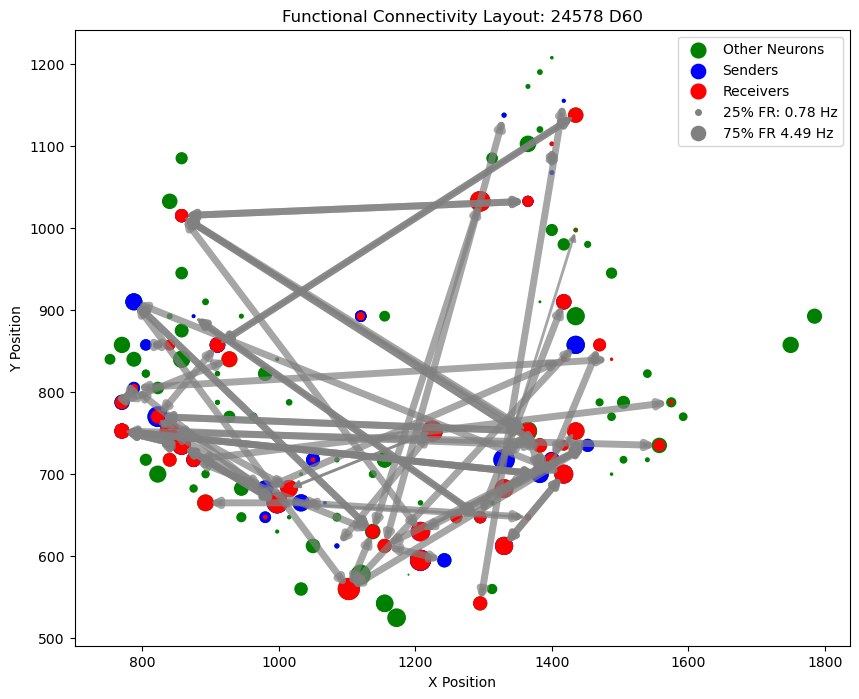

In [97]:
plot_functional_connectivity(sd24578_60, fp24578_60, base_line_scale=1, max_line_width=5, title= "24578 D60")